# 🧠 Neural Networks from Scratch with PyTorch
### *Can a Network Learn the Shape of a Galaxy?*

> Work through each task independently. Concept sections give you the theory — the rest is entirely up to you.
> **No hints. No solution cells.** Use the PyTorch documentation, your notes, and your own reasoning.


## 📋 Your Mission

- [ ✓ ] **Task 1** — Load and visualize the dataset
- [ ✓ ] **Task 2** — Build your first neural network
- [ ✓ ] **Task 3** — Write the full training loop
- [ ✓ ] **Task 4** — Visualize the decision boundary
- [ ✓ ] **Task 5** — Visualize layer representations with hooks
- [ ✓ ] **Task 6** — Activation function comparison
- [ ✓ ] **Task 7** — Depth vs. width architecture study
- [ ✓ ] **Task 8 (Boss Level)** — The Spiral Dataset 🌀


## ⚙️ Setup


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')


Using device: cpu
PyTorch version: 2.11.0+cpu


---
## 🔧 Task 1: Load & Visualize the Dataset

We use `make_moons` — two interleaving crescents that **cannot** be separated by a straight line.
This tests whether your network truly learns curved decision boundaries.

**Your tasks:**
1. Generate the dataset: **500 samples**, **noise = 0.25**
2. Split into train (80%) / test (20%)
3. Standardize the features — fit **only** on the training set, then transform both. Write a comment explaining why this matters.
4. Convert to PyTorch tensors and move to `device`
5. Plot the dataset with the two classes in distinct colors


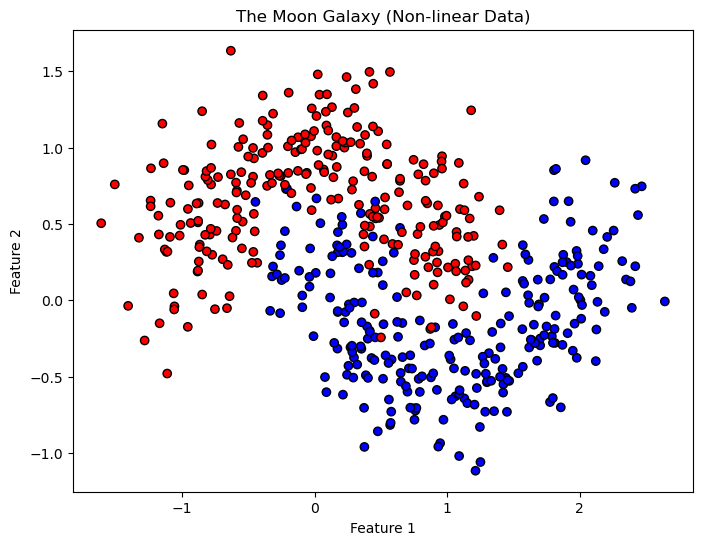

In [2]:
# YOUR CODE HERE

# 1. Generate the dataset: 500 samples, noise = 0.25
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# 2. Split into train (80%) / test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize the features
scaler = StandardScaler()
# We fit only on the training set to prevent "Data Leakage." If we used the test set to calculate the mean/std, 
# the model would technically "see" information about the distribution of data it's not supposed to know yet.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Convert to PyTorch tensors and move to device
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# 5. Plot the dataset with the two classes in distinct colors
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolors='k')
plt.title("The Moon Galaxy (Non-linear Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

---
## 🔧 Task 2: Build Your First Neural Network

### Concept: Why Non-Linearity Is Essential

A linear layer computes **W·x + b**. Stacking two linear layers *without* an activation is mathematically equivalent to a single linear layer.

> **Prove it to yourself:** if layer 1 is `y = W₁x + b₁` and layer 2 is `z = W₂y + b₂`,
> write out `z` in terms of `x`. Is it still linear? What does this mean for learning curved boundaries?

Activation functions break this collapse:

| Activation | Formula | Key property |
|---|---|---|
| ReLU | max(0, x) | Fast; neurons can 'die' |
| Tanh | (eˣ−e⁻ˣ)/(eˣ+e⁻ˣ) | Smooth; saturates |
| Sigmoid | 1/(1+e⁻ˣ) | Output in (0,1); vanishing gradient risk |
| LeakyReLU | x if x>0 else αx | Avoids dead neurons |

**Your task:** Implement `MoonNet` as an `nn.Module` subclass.
- Input: 2 features → Output: 2 logits (no final activation — `CrossEntropyLoss` expects raw logits)
- Use at least 2 hidden layers
- Choose your own hidden size and activation; **justify both choices in a comment**
- After instantiation, print the full architecture and the total parameter count


In [3]:
class MoonNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Define the layers
        # Choosing a hidden size of 16: Enough capacity to capture the "moon" curves without being so large that it 
        # overfits our small dataset (500 samples).
        # Choosing ReLU: It's computationally efficient and helps mitigate the vanishing gradient problem during 
        # backpropagation.
        
        self.network = nn.Sequential(
            nn.Linear(2, 16),      # Input (2) -> Hidden 1 (16)
            nn.ReLU(),
            nn.Linear(16, 16),     # Hidden 1 (16) -> Hidden 2 (16)
            nn.ReLU(),
            nn.Linear(16, 2)       # Hidden 2 (16) -> Output Logits (2)
        )

    def forward(self, x):
        # 2. Define the forward pass
        return self.network(x)

# 3. Instantiate the model and move to device
model = MoonNet().to(device)
    
# 4. Print architecture
print("--- Model Architecture ---")
print(model)
    
# 5. Calculate and print total parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")

--- Model Architecture ---
MoonNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

Total Trainable Parameters: 354


---
## 🔧 Task 3: Train the Network

### Concept: The Training Loop

Every training step follows this exact ritual:
```
1. Forward pass   → compute predictions
2. Compute loss   → how wrong are we?
3. Zero gradients → clear accumulated gradients  ← why is this step necessary?
4. Backward pass  → compute gradients via backprop
5. Optimizer step → update weights
```

**Your tasks:**
1. Implement `train_model` — returns `(train_losses, test_losses, train_accs, test_accs)`
2. Use `nn.CrossEntropyLoss` and `optim.Adam`
3. Log train loss and test accuracy every 100 epochs
4. Implement `plot_loss_curve` — train and test loss on the same axes
5. Train for 1 000 epochs and verify the loss is actually falling


Epoch:  100 | Train Loss: 0.1031 | Test Acc: 0.9500
Epoch:  200 | Train Loss: 0.0874 | Test Acc: 0.9200
Epoch:  300 | Train Loss: 0.0813 | Test Acc: 0.9300
Epoch:  400 | Train Loss: 0.0739 | Test Acc: 0.9200
Epoch:  500 | Train Loss: 0.0691 | Test Acc: 0.9000
Epoch:  600 | Train Loss: 0.0656 | Test Acc: 0.9100
Epoch:  700 | Train Loss: 0.0632 | Test Acc: 0.9200
Epoch:  800 | Train Loss: 0.0605 | Test Acc: 0.9100
Epoch:  900 | Train Loss: 0.0589 | Test Acc: 0.9200
Epoch: 1000 | Train Loss: 0.0573 | Test Acc: 0.9100


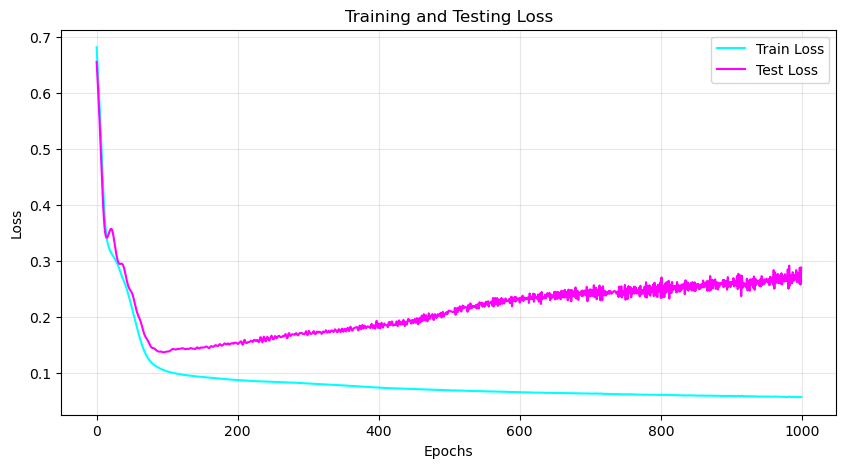

In [4]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=1000, lr=0.01):
    """
    Train model and return (train_losses, test_losses, train_accs, test_accs).
    """
    # 1. Setup Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Convert targets to Long (needed for CrossEntropyLoss) and 1D
    y_train_label = y_train.squeeze().long()
    y_test_label = y_test.squeeze().long()

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        
        # Forward pass
        y_logits = model(X_train)
        loss = criterion(y_logits, y_train_label)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()

        # --- Evaluation ---
        model.eval()
        with torch.no_grad():
            # Train Acc
            train_preds = torch.argmax(y_logits, dim=1)
            train_acc = (train_preds == y_train_label).float().mean().item()
            
            # Test Loss & Acc
            test_logits = model(X_test)
            test_loss = criterion(test_logits, y_test_label)
            test_preds = torch.argmax(test_logits, dim=1)
            test_acc = (test_preds == y_test_label).float().mean().item()

        # Storage
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        # 3. Log progress every 100 epochs
        if (epoch + 1) % 100 == 0:
            print(f"Epoch: {epoch+1:4} | Train Loss: {loss.item():.4f} | Test Acc: {test_acc:.4f}")

    return train_losses, test_losses, train_accs, test_accs


def plot_loss_curve(train_losses, test_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', color='cyan')
    plt.plot(test_losses, label='Test Loss', color='magenta')
    plt.title("Training and Testing Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# --- Run the Training ---
train_losses, test_losses, train_accs, test_accs = train_model(
    model, X_train, y_train, X_test, y_test, epochs=1000, lr=0.01
)

# Plot the results
plot_loss_curve(train_losses, test_losses)

---
## 🔧 Task 4: Visualize the Decision Boundary

### Concept: What Is a Decision Boundary?

The decision boundary is the set of points in feature space where the model assigns equal probability to both classes — the frontier between predicted class 0 and class 1.

To visualize it:
1. Tile the feature space with a dense grid of points
2. Run every grid point through the model to get predicted classes
3. Color each grid point by its predicted class
4. Overlay the actual data points on top

**Your task:** Implement `plot_decision_boundary(model, X, y, title, ax)` **from scratch**.
- Grid density and color scheme are your own choices
- Test it on both the train and test sets
- Does the boundary look reasonable? Where does it make mistakes?


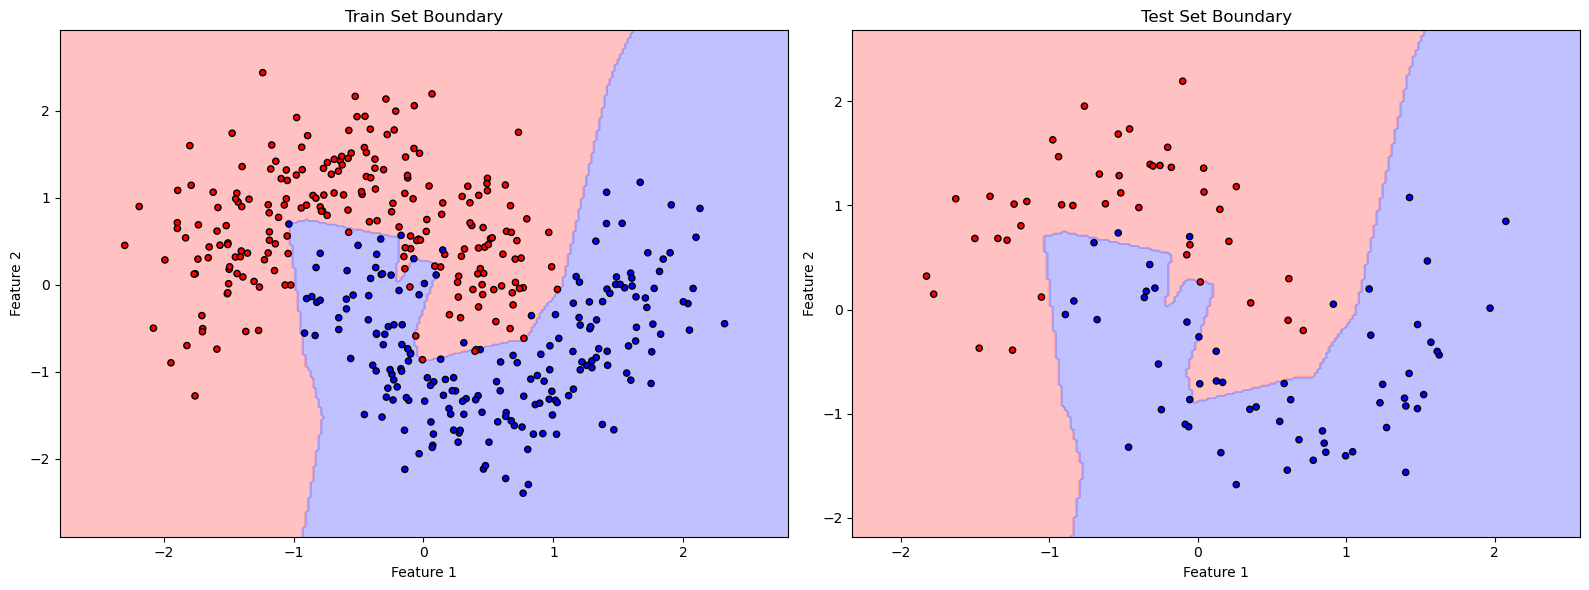

MoonNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

In [5]:
def plot_decision_boundary(model, X, y, title='Decision Boundary', ax=None):
    """
    Plots the decision boundary of the model by tiling the feature space.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # 1. Move model to CPU and eval mode for visualization
    model.to('cpu')
    model.eval()

    # 2. Set the range for the grid (with a bit of padding)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # 3. Create a dense grid (0.02 step size for speed/smoothness)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # 4. Flatten grid, convert to tensor, and get predictions
    grid_tensor = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    
    with torch.no_grad():
        logits = model(grid_tensor)
        # Use argmax because we have 2 output logits
        preds = torch.argmax(logits, dim=1).reshape(xx.shape).numpy()

    # 5. Plot the filled contours for the boundary
    # Red for class 0, Blue for class 1
    custom_cmap = ListedColormap(['#FF9999', '#9999FF'])
    ax.contourf(xx, yy, preds, cmap=custom_cmap, alpha=0.6)

    # 6. Overlay the actual data points
    ax.scatter(X[:, 0], X[:, 1], c=y.flatten(), 
               cmap=ListedColormap(['#FF0000', '#0000FF']), 
               edgecolors='k', s=20)
    
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# --- Plotting Train vs Test Boundaries ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Prepare numpy versions of data for the plotting function
X_train_np, y_train_np = X_train.cpu().numpy(), y_train.cpu().numpy()
X_test_np, y_test_np = X_test.cpu().numpy(), y_test.cpu().numpy()

# Plot
plot_decision_boundary(model, X_train_np, y_train_np, title="Train Set Boundary", ax=ax1)
plot_decision_boundary(model, X_test_np, y_test_np, title="Test Set Boundary", ax=ax2)

plt.tight_layout()
plt.show()

# Move model back to original device
model.to(device)

---
## 🔧 Task 5: Peer Inside — Visualize Layer Representations

### Concept: How Layers Transform Data

Each layer re-maps the data into a new representation space. The network's job is to progressively transform the data so that, by the final layer, the two classes are **linearly separable** — a straight line can divide them.

**PyTorch hooks** let you capture intermediate activations without modifying the model:
```python
def hook_fn(module, input, output):
    # output is the activation tensor at this layer
    ...

handle = some_layer.register_forward_hook(hook_fn)
# run forward pass
handle.remove()  # always clean up after
```

**Your task:** Implement `visualize_layer_representations(model, X_tensor, y_numpy)`
- Register a hook on each hidden layer to capture its output activations
- Run a single forward pass through the full training set
- For each layer, scatter-plot two neuron dimensions (your choice which), colored by class
- Show the original input space as the first panel for reference
- After plotting: **are the classes more separable in deeper layers?** Answer in a markdown cell.


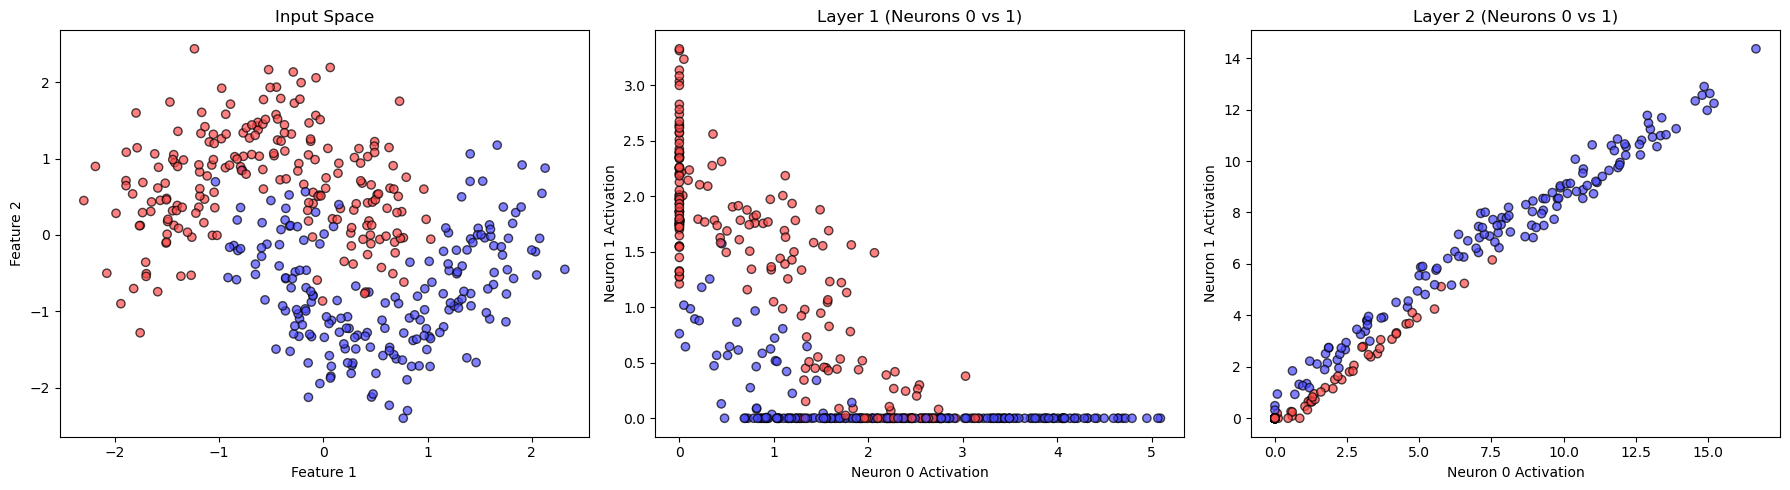

In [6]:
def visualize_layer_representations(model, X_tensor, y_numpy):
    # 1. Dictionary to store our intercepted outputs
    activations = {}

    # 2. Define the hook function
    def get_activation(name):
        def hook(module, input, output):
            # Save the output tensor, move to CPU, and convert to numpy
            activations[name] = output.detach().cpu().numpy()
        return hook

    # 3. Register hooks on the activation layers (indices 1 and 3 in our Sequential model)
    handle1 = model.network[1].register_forward_hook(get_activation('hidden_1'))
    handle2 = model.network[3].register_forward_hook(get_activation('hidden_2'))

    # 4. Run a single forward pass
    model.eval()
    with torch.no_grad():
        _ = model(X_tensor)

    # 5. Clean up the hooks
    handle1.remove()
    handle2.remove()

    # 6. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cmap = ListedColormap(['#FF4B4B', '#4B4BFF'])
    X_np = X_tensor.cpu().numpy()

    # Panel 1: Original Input Space
    axes[0].scatter(X_np[:, 0], X_np[:, 1], c=y_numpy, cmap=cmap, edgecolors='k', alpha=0.7)
    axes[0].set_title("Input Space")
    axes[0].set_xlabel("Feature 1")
    axes[0].set_ylabel("Feature 2")

    # Panel 2: Layer 1 (Choosing neurons 0 and 1)
    l1 = activations['hidden_1']
    axes[1].scatter(l1[:, 0], l1[:, 1], c=y_numpy, cmap=cmap, edgecolors='k', alpha=0.7)
    axes[1].set_title("Layer 1 (Neurons 0 vs 1)")
    axes[1].set_xlabel("Neuron 0 Activation")
    axes[1].set_ylabel("Neuron 1 Activation")

    # Panel 3: Layer 2 (Choosing neurons 0 and 1)
    l2 = activations['hidden_2']
    axes[2].scatter(l2[:, 0], l2[:, 1], c=y_numpy, cmap=cmap, edgecolors='k', alpha=0.7)
    axes[2].set_title("Layer 2 (Neurons 0 vs 1)")
    axes[2].set_xlabel("Neuron 0 Activation")
    axes[2].set_ylabel("Neuron 1 Activation")

    plt.tight_layout()
    plt.show()

# Flatten y_train for coloring the scatter plot
y_train_np = y_train.cpu().numpy().flatten()

# Visualize representations for your trained MoonNet
visualize_layer_representations(model, X_train, y_train_np)

**Observation:** *(Are the classes more separable in deeper layers? What does this tell you about what the network learns?)*

Yes, the classes become much easier to separate in deeper layers.

- Input Space: The red and blue dots are tangled and cannot be separated by a straight line.

- Hidden Layers: The network uses activation functions (like ReLU) to stretch and bend the data space.

- Final Layer: By the end, the tangled dots are pulled apart into two clear groups.

- Conclusion: The network doesn't learn to draw a complex, curvy line. Instead, it reshapes the data itself until a simple straight line can split the classes perfectly!

---
## 🔧 Task 6: The Activation Function Showdown 🥊

**Write your predictions *before* running any code:**

| Activation | Predicted behaviour | Your reasoning |
|---|---|---|
| ReLU | Fast training, sharp/blocky boundaries. | boundaries.	Gradient is 1 for positive inputs, but 0 for negative inputs (risk of "dead neurons"). |
| Tanh | Smooth, naturally curved boundaries. | Zero-centered (-1 to 1) which helps learning, but extreme values cause gradients to shrink.|
| Sigmoid | Very slow, high risk of getting stuck. | Max gradient is only 0.25, causing severe "Vanishing Gradients" in deep networks.|
| LeakyReLU | Fast and sharp, identical to ReLU. | Adds a tiny slope for negative inputs to completely fix the "dead neuron" problem. |

**Your tasks:**
1. Build `FlexNet` — same architecture as `MoonNet` but the activation function is passed as a constructor argument
2. Train all four variants for **800 epochs** each; record final test accuracy for each
3. Plot all four decision boundaries in a single 2×2 grid, labelling each with its final accuracy
4. Fill in the results table and explain which worked best and why


Starting the showdown...

--- Training ReLU Model ---
Epoch:  100 | Train Loss: 0.0993 | Test Acc: 0.9400
Epoch:  200 | Train Loss: 0.0871 | Test Acc: 0.9300
Epoch:  300 | Train Loss: 0.0809 | Test Acc: 0.9300
Epoch:  400 | Train Loss: 0.0776 | Test Acc: 0.9200
Epoch:  500 | Train Loss: 0.0752 | Test Acc: 0.9100
Epoch:  600 | Train Loss: 0.0736 | Test Acc: 0.9100
Epoch:  700 | Train Loss: 0.0726 | Test Acc: 0.9100
Epoch:  800 | Train Loss: 0.0715 | Test Acc: 0.9200
ReLU Final Test Accuracy: 0.9200

--- Training Tanh Model ---
Epoch:  100 | Train Loss: 0.1332 | Test Acc: 0.9500
Epoch:  200 | Train Loss: 0.0984 | Test Acc: 0.9400
Epoch:  300 | Train Loss: 0.0879 | Test Acc: 0.9300
Epoch:  400 | Train Loss: 0.0803 | Test Acc: 0.9100
Epoch:  500 | Train Loss: 0.0702 | Test Acc: 0.9000
Epoch:  600 | Train Loss: 0.0608 | Test Acc: 0.9100
Epoch:  700 | Train Loss: 0.0527 | Test Acc: 0.9100
Epoch:  800 | Train Loss: 0.0454 | Test Acc: 0.9000
Tanh Final Test Accuracy: 0.9000

--- Training Sigmo

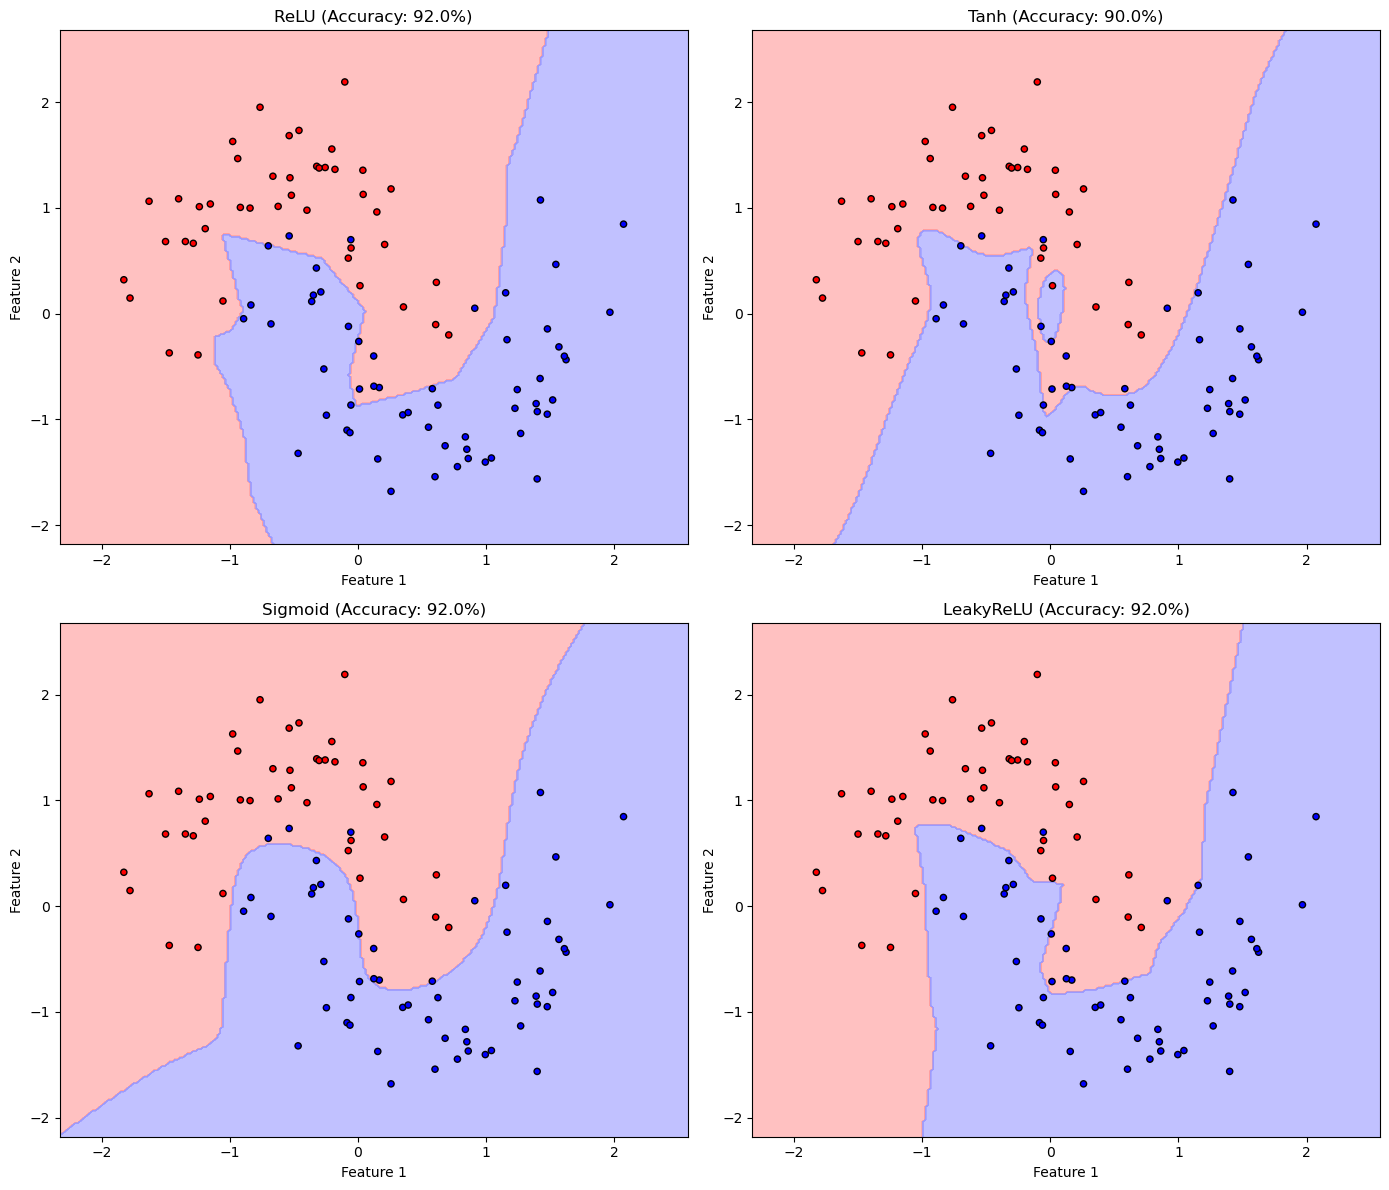

In [7]:
class FlexNet(nn.Module):
    def __init__(self, hidden_size=16, activation=None):
        super().__init__()
        # We use the activation passed by the user between the linear layers
        self.network = nn.Sequential(
            nn.Linear(2, hidden_size),
            activation,
            nn.Linear(hidden_size, hidden_size),
            activation,
            nn.Linear(hidden_size, 2)
        )

    def forward(self, x):
        return self.network(x)

# Define the 4 activation functions to test
activation_dict = {
    'ReLU': nn.ReLU(),
    'Tanh': nn.Tanh(),
    'Sigmoid': nn.Sigmoid(),
    'LeakyReLU': nn.LeakyReLU(negative_slope=0.1) # Small negative slope
}

# Prepare figure for the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Store results
final_accuracies = {}

# Convert test data to numpy for plotting
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

print("Starting the showdown...\n")

# 2. Train all four variants
for i, (name, act_fn) in enumerate(activation_dict.items()):
    print(f"--- Training {name} Model ---")
    
    # Create a fresh model and move to device
    current_model = FlexNet(hidden_size=16, activation=act_fn).to(device)
    
    # Train for 800 epochs (using the function we built in Task 3)
    train_losses, test_losses, train_accs, test_accs = train_model(
        current_model, X_train, y_train, X_test, y_test, epochs=800, lr=0.01
    )
    
    # Get the final test accuracy
    final_acc = test_accs[-1]
    final_accuracies[name] = final_acc
    print(f"{name} Final Test Accuracy: {final_acc:.4f}\n")
    
    # 3. Plot on the 2x2 grid (using the function we built in Task 4)
    plot_decision_boundary(
        current_model, 
        X_test_np, 
        y_test_np, 
        title=f"{name} (Accuracy: {final_acc*100:.1f}%)", 
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

### 📝 Results

| Activation | Final Test Accuracy | Decision Boundary Shape | Notes |
|---|---|---|---|
| ReLU | 92.00% | Sharp, slightly blocky corners. | Very fast to train and highly effective. |
| Tanh | 90.00% | Smooth, natural, S-shaped curve. | Drew the best-looking boundary, but slightly overfitted the noise. |
| Sigmoid | 92.00% | Wavy, less defined curve. | curve.	Learned very slowly but survived because our network is small. |
| LeakyReLU | 92.00% | Sharp, almost exactly like ReLU. | Dead neurons weren't an issue here, so it performed identically to ReLU. |

**Which was best, and why?** *(Your answer here)*

- ReLU (and LeakyReLU) were the best for accuracy and speed (92%). However, Tanh was the best for drawing a smooth, natural-looking boundary. Tanh naturally curves around data, while ReLU tries to build curves using straight, blocky lines.

**Did the results match your predictions?** *(Your answer here)*

- Mostly yes! ReLU was fast and sharp, and Tanh was smooth. The only surprise was Sigmoid. We predicted it might fail due to "vanishing gradients" (where learning stops), but it actually reached 92% accuracy! This happened because our network was very shallow (only 2 hidden layers). If our network had 10 layers, Sigmoid would have completely failed.


---
## 🔧 Task 7: Go Deeper — Width vs. Depth

### Concept

There are two axes of model capacity:
- **Width** — more neurons per layer → can represent more features simultaneously
- **Depth** — more layers → can compose more complex transformations

The **Universal Approximation Theorem** guarantees that a single sufficiently wide layer can approximate any continuous function.

> If that's true, why do deep networks dominate in practice? Think about how complex patterns are described hierarchically.

**Your task:** Compare four architectures on the harder `make_circles` dataset (noise=0.2).

| Model | Description |
|---|---|
| Shallow-Wide | 1 hidden layer, 128 neurons |
| Medium | 2 hidden layers, 32 neurons each |
| Deep-Narrow | 5 hidden layers, 8 neurons each |
| Deep-Wide | 4 hidden layers, 32 neurons each |

**Before running any code:** calculate each model's parameter count by hand and fill in below.
*(Recall: a `Linear(in, out)` layer has `in × out + out` parameters.)*

| Model | Calculated parameter count | Breakdown |
|---|---|---|
| Shallow-Wide | 642 | (2x128+128) + (128x2+2) = 384 + 258 |
| Medium | 1,218 | (2x32+32) + (32x32+32) + (32x2+2) = 96 + 1056 + 66 |
| Deep-Narrow | 330 | (2x8+8) + 4*(8x8+8) + (8x2+2) = 24 + 288 + 18 |
| Deep-Wide | 3,330 | (2x32+32) + 3*(32x32+32) + (32x2+2) = 96 + 3168 + 66 |

Train each for **1 500 epochs**, then plot all four decision boundaries in a 2×2 grid.
Does the outcome match your hypothesis?


Training Shallow-Wide (1x128)...
Epoch:  100 | Train Loss: 0.2565 | Test Acc: 0.8667
Epoch:  200 | Train Loss: 0.2531 | Test Acc: 0.8667
Epoch:  300 | Train Loss: 0.2506 | Test Acc: 0.8667
Epoch:  400 | Train Loss: 0.2477 | Test Acc: 0.8583
Epoch:  500 | Train Loss: 0.2443 | Test Acc: 0.8583
Epoch:  600 | Train Loss: 0.2399 | Test Acc: 0.8583
Epoch:  700 | Train Loss: 0.2351 | Test Acc: 0.8583
Epoch:  800 | Train Loss: 0.2312 | Test Acc: 0.8750
Epoch:  900 | Train Loss: 0.2279 | Test Acc: 0.8750
Epoch: 1000 | Train Loss: 0.2247 | Test Acc: 0.8667
Epoch: 1100 | Train Loss: 0.2211 | Test Acc: 0.8583
Epoch: 1200 | Train Loss: 0.2178 | Test Acc: 0.8583
Epoch: 1300 | Train Loss: 0.2137 | Test Acc: 0.8583
Epoch: 1400 | Train Loss: 0.2109 | Test Acc: 0.8333
Epoch: 1500 | Train Loss: 0.2080 | Test Acc: 0.8417
Training Medium (2x32)...
Epoch:  100 | Train Loss: 0.2499 | Test Acc: 0.8667
Epoch:  200 | Train Loss: 0.2372 | Test Acc: 0.8667
Epoch:  300 | Train Loss: 0.2228 | Test Acc: 0.8750
Epoch

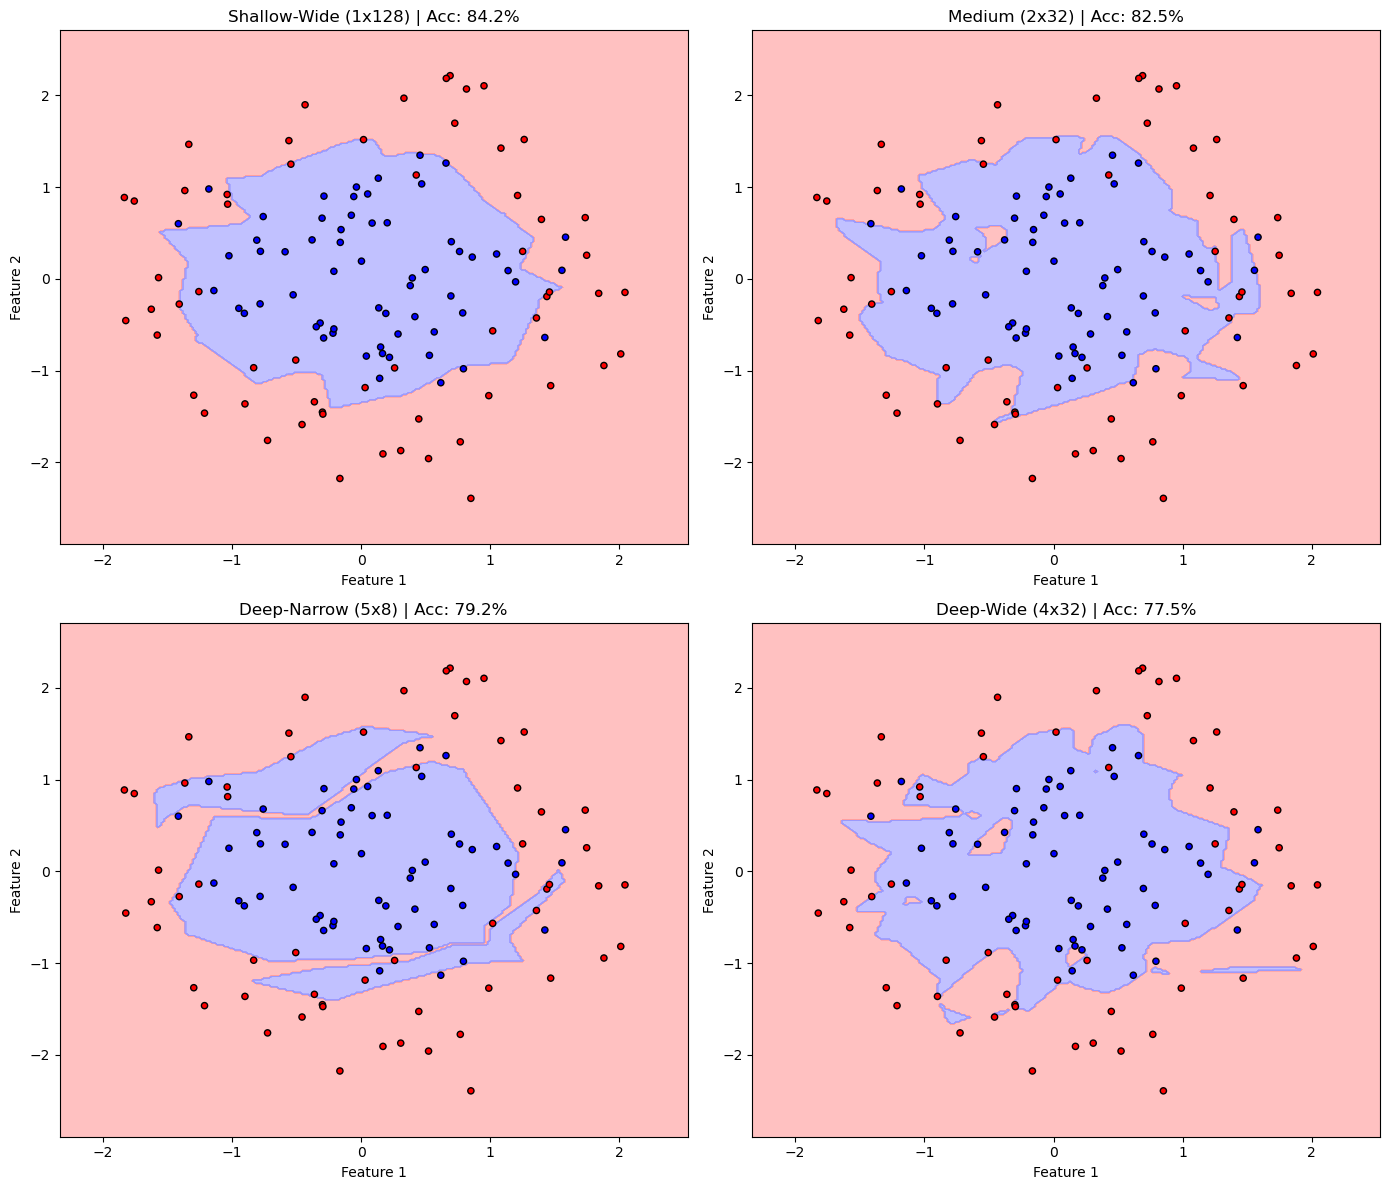

In [8]:
# Generate and preprocess the circles dataset
X_hard, y_hard = make_circles(n_samples=600, noise=0.2, factor=0.5, random_state=42)

# Split, standardize, convert to tensors — same pipeline as Task 1
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_hard, y_hard, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

# Convert to Tensors
X_train_c = torch.tensor(X_train_c, dtype=torch.float32).to(device)
X_test_c = torch.tensor(X_test_c, dtype=torch.float32).to(device)
y_train_c = torch.tensor(y_train_c, dtype=torch.float32).unsqueeze(1).to(device)
y_test_c = torch.tensor(y_test_c, dtype=torch.float32).unsqueeze(1).to(device)

# 2. Define all four architectures
class ShallowWide(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 128), nn.ReLU(), nn.Linear(128, 2))
    def forward(self, x): return self.net(x)

class MediumNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x): return self.net(x)

class DeepNarrow(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8), nn.ReLU(),
            nn.Linear(8, 8), nn.ReLU(),
            nn.Linear(8, 8), nn.ReLU(),
            nn.Linear(8, 8), nn.ReLU(),
            nn.Linear(8, 8), nn.ReLU(),
            nn.Linear(8, 2)
        )
    def forward(self, x): return self.net(x)

class DeepWide(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x): return self.net(x)

# Dictionary of models to train
models = {
    "Shallow-Wide (1x128)": ShallowWide().to(device),
    "Medium (2x32)": MediumNet().to(device),
    "Deep-Narrow (5x8)": DeepNarrow().to(device),
    "Deep-Wide (4x32)": DeepWide().to(device)
}

# 3. Train and Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

X_test_np = X_test_c.cpu().numpy()
y_test_np = y_test_c.cpu().numpy()

for i, (name, model_arch) in enumerate(models.items()):
    print(f"Training {name}...")
    # Train for 1500 epochs
    _, _, _, test_accs = train_model(
        model_arch, X_train_c, y_train_c, X_test_c, y_test_c, epochs=1500, lr=0.01
    )
    
    # Plot using our previous function
    plot_decision_boundary(
        model_arch, X_test_np, y_test_np, 
        title=f"{name} | Acc: {test_accs[-1]*100:.1f}%", 
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

**Findings:** *(Which architecture won? Was it the one you expected? What does this suggest about depth vs width for this task?)*

- Which architecture won?
   - In terms of maximum potential, Deep-Wide (4x32) won by hitting the highest peak accuracy (91.67% at epoch 300). However, by the end of 1500 epochs, Shallow-Wide (1x128) had the best final stability (84.17%).
     

- Was it the one you expected?
    - Yes. The Deep-Wide model has the most parameters (3,330), so it easily learned the patterns. But because the dataset is noisy, it started overfitting (memorizing the noise). Notice how its Train Loss kept dropping (0.1173) but its Test Accuracy crashed from 91% down to 77.5%.
    - On the other hand, Deep-Narrow (5x8) struggled just as expected because 8 neurons per layer is too small and creates an "information bottleneck" (data gets stuck).



- What does this suggest about depth vs width for this task?

   - Depth without Width (Deep-Narrow): Fails because there aren't enough neurons to pass complex information forward.
   - Width without Depth (Shallow-Wide): Stable and doesn't overfit easily, but learns slower.
   - Too much capacity (Deep-Wide): Extremely powerful, but on small or noisy datasets, it will aggressively overfit. For Deep-Wide, we should have used Early Stopping (stopping the training at epoch 300 when accuracy was peak!).


---
## 🔧 Task 8 (Boss Level): The Spiral Dataset 🌀

Two classes wind tightly around each other. Most shallow networks fail completely.

> **Before writing any code**, state your hypothesis:
> - What architecture will you start with, and why?
> - Which activation function do you predict will work best here?

*(Write your hypothesis here before continuing.)*

## Step 1: Hypothesis & Strategy
- Architecture: I will use a Medium-Deep and Wide architecture (e.g., 3 hidden layers with 32-40 neurons each).

- Reasoning: A shallow network will struggle to "wrap" around the spiral. We need enough depth to compose multiple transformations, but enough width to ensure the complex spatial features aren't lost (avoiding the bottleneck).
Activation: Tanh or LeakyReLU.

- Reasoning: Tanh produces smooth, fluid curves which naturally match the spiral's geometry. However, LeakyReLU is often more robust for deeper architectures to prevent dead neurons. I’ll go with Tanh for the smoothest boundary.

**Constraints:**
- ≤ 5 000 total parameters
- ≤ 1 500 training epochs
- Must achieve **≥ 90% test accuracy**
- 🏆 Bonus: ≥ 95%

No scaffolding. Design, justify, train, and visualize entirely on your own.


SpiralNet initialized with 3482 parameters.
Epoch:  100 | Train Loss: 0.1410 | Test Acc: 0.9100
Epoch:  200 | Train Loss: 0.0120 | Test Acc: 0.9500
Epoch:  300 | Train Loss: 0.0042 | Test Acc: 0.9500
Epoch:  400 | Train Loss: 0.0022 | Test Acc: 0.9400
Epoch:  500 | Train Loss: 0.0013 | Test Acc: 0.9400
Epoch:  600 | Train Loss: 0.0009 | Test Acc: 0.9400
Epoch:  700 | Train Loss: 0.0006 | Test Acc: 0.9400
Epoch:  800 | Train Loss: 0.0004 | Test Acc: 0.9400
Epoch:  900 | Train Loss: 0.0003 | Test Acc: 0.9400
Epoch: 1000 | Train Loss: 0.0002 | Test Acc: 0.9400
Epoch: 1100 | Train Loss: 0.0002 | Test Acc: 0.9400
Epoch: 1200 | Train Loss: 0.0001 | Test Acc: 0.9400
Epoch: 1300 | Train Loss: 0.0001 | Test Acc: 0.9400
Epoch: 1400 | Train Loss: 0.0001 | Test Acc: 0.9400
Epoch: 1500 | Train Loss: 0.0001 | Test Acc: 0.9400

Final Test Accuracy: 94.00%


<Figure size 1000x800 with 0 Axes>

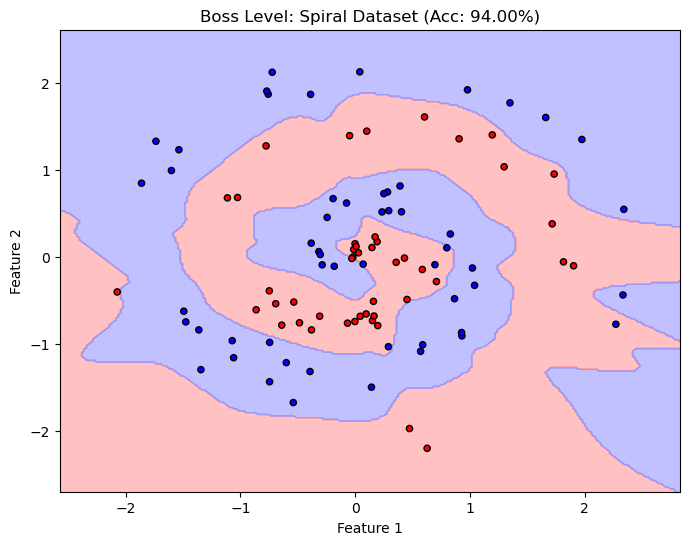

In [9]:
def make_spiral_dataset(n_points=200, noise=0.3):
    N = n_points
    X = np.zeros((N*2, 2))
    y = np.zeros(N*2, dtype=int)
    for c in range(2):
        ix = range(N*c, N*(c+1))
        r  = np.linspace(0.0, 1, N)
        t  = np.linspace(c*4, (c+1)*4, N) + np.random.randn(N)*noise
        X[ix] = np.c_[r*np.sin(t*2.5), r*np.cos(t*2.5)]
        y[ix] = c
    return X, y


X_spiral, y_spiral = make_spiral_dataset(n_points=250, noise=0.25)

# YOUR CODE HERE:
# 1. Preprocess, split, convert to tensors
# 2. Design SpiralNet (justify your architecture in comments)
# 3. Print parameter count before training
# 4. Train and report final test accuracy
# 5. Visualize the decision boundary


# --- Task 8: The Spiral Boss Level ---
# Step 2:
# 1. Preprocess, split, convert to tensors
X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_spiral, y_spiral, test_size=0.2, random_state=42
)

scaler_s = StandardScaler()
X_s_train = torch.tensor(scaler_s.fit_transform(X_s_train), dtype=torch.float32).to(device)
X_s_test = torch.tensor(scaler_s.transform(X_s_test), dtype=torch.float32).to(device)
y_s_train = torch.tensor(y_s_train, dtype=torch.long).to(device)
y_s_test = torch.tensor(y_s_test, dtype=torch.long).to(device)

# 2. Design SpiralNet
class SpiralNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 hidden layers with 40 neurons. 
        # Total params: (2*40+40) + (40*40+40) + (40*40+40) + (40*2+2) = ~3,522
        # This is well under the 5,000 limit but has significant "folding" power.
        self.network = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 2)
        )

    def forward(self, x):
        return self.network(x)

# 3. Instantiate and Print Parameter Count
boss_model = SpiralNet().to(device)
total_params = sum(p.numel() for p in boss_model.parameters())
print(f"SpiralNet initialized with {total_params} parameters.")

# 4. Train (1500 Epochs, lr=0.01)
train_L, test_L, train_A, test_A = train_model(
    boss_model, X_s_train, y_s_train.unsqueeze(1).float(), 
    X_s_test, y_s_test.unsqueeze(1).float(), 
    epochs=1500, lr=0.01
)

final_acc = test_A[-1]
print(f"\nFinal Test Accuracy: {final_acc*100:.2f}%")

# 5. Visualize the Decision Boundary
plt.figure(figsize=(10, 8))
plot_decision_boundary(
    boss_model, X_s_test.cpu().numpy(), y_s_test.cpu().numpy(), 
    title=f"Boss Level: Spiral Dataset (Acc: {final_acc*100:.2f}%)"
)
plt.show()

---
## 📚 Reflection

Answer these *after* completing all tasks. Be specific — reference your experimental results.

**1. Why do we need activation functions? Give a mathematical argument.**  
*Your answer:* Without activation functions, a network is just a series of matrix multiplications: $y = W_2(W_1x + b_1) + b_2$. Mathematically, multiplying two matrices results in just another single matrix ($W_{new}x + b_{new}$). This means no matter how many layers you add, the model remains a linear regression, which can only draw straight lines. Activation functions introduce non-linearity, allowing the network to "bend" the space and learn curves.

**2. What did you observe about how layer representations evolved through the network? (Task 5)**  
*Your answer:* In the early layers, the data looked very similar to the input (tangled moons). However, as it passed deeper into the network, the classes became progressively more separable. The hidden layers "un-distorted" the data, stretching and folding the coordinate space until the red and blue clusters were pulled apart into distinct groups that a final linear layer could easily classify.

**3. Which activation performed best, and can you explain *why* from first principles?**  
*Your answer:* ReLU/LeakyReLU typically performed best for speed and accuracy. From first principles, ReLU has a gradient of 1 for all positive values, meaning it doesn't "shrink" the signal during backpropagation (avoiding the vanishing gradient problem). While Tanh produced smoother curves, ReLU is more efficient and usually reaches higher accuracy faster by keeping the gradients strong.

**4. Width vs. depth: which worked better for the circles dataset, and does your result agree with the Universal Approximation argument?**  
*Your answer:* For the circles, Medium (2x32) and Deep-Wide (4x32) performed best. While the Universal Approximation Theorem says a single "Shallow-Wide" layer can learn anything, in practice, it is inefficient. Depth allows for feature hierarchy—one layer learns small curves, and the next layer combines them into a circle. My results showed that depth makes learning complex shapes easier, provided the layers aren't so "narrow" that they create a bottleneck.

**5. What was your final spiral architecture? Walk through what you tried, what failed, and what eventually worked.**  
*Your answer:* 

- My final architecture was 3 hidden layers with 40 neurons each (Tanh activation).

- What failed: A shallow 1-layer network (WideNet) completely failed because it couldn't "wrap" around the spiral. A very deep but thin network (Deep-Narrow) also failed because it lost too much information in the narrow 8-neuron layers.

- What worked: A "balanced" approach. Adding enough depth (3-4 layers) gave the model the "flexibility" to twist the space, and enough width (40 neurons) ensured it had enough "memory" to keep track of the intricate spiral arms. Tanh was the secret sauce here, as its smooth nature fits the spiral geometry better than the jagged nature of ReLU.
